In [19]:
import numpy as np
from matplotlib import rc
import matplotlib.pyplot as plt


def plot_cobweb(f, r, x0, nmax=50):
    """Make a cobweb plot.

    Plot y = f(x; r) and y = x for 0 <= x <= 1, and illustrate the behaviour of
    iterating x = f(x) starting at x = x0. r is a parameter to the function.

    """
    dpi = 100
    x = np.linspace(0, 2, 500)
    fig = plt.figure(figsize=(600/dpi, 450/dpi), dpi=dpi)
    ax = fig.add_subplot(111)

    # Plot y = f(x) and y = x
    ax.plot(x, f(x, r), c='#444444', lw=2)
    ax.plot(x, x, c='#444444', lw=2)

    # Iterate x = f(x) for nmax steps, starting at (x0, 0).
    px, py = np.empty((2,nmax+1,2))
    px[0], py[0] = x0, 0
    for n in range(1, nmax, 2):
        px[n] = px[n-1]
        py[n] = f(px[n-1], r)
        px[n+1] = py[n]
        py[n+1] = py[n]

    # Plot the path traced out by the iteration.
    ax.plot(px, py, c='b', alpha=0.7)

    # Annotate and tidy the plot.
    ax.minorticks_on()
    ax.grid(which='minor', alpha=0.5)
    ax.grid(which='major', alpha=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f(x)$')
    ax.set_title('$x_0 = {:.1}, r = {:.3}$'.format(x0, r))


In [20]:
def f(x, r):
    return np.sin(x)+np.cos(x)


In [21]:
x0 = 0.1

r = 2.1


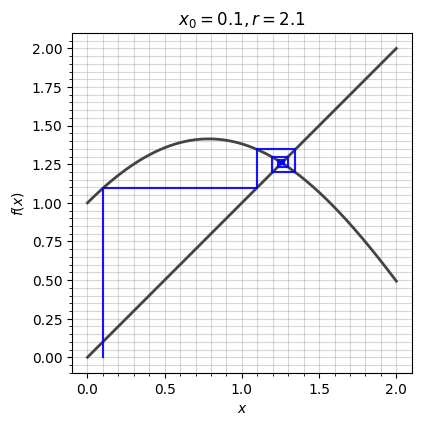

In [22]:
plot_cobweb(f, r, x0)

In [30]:
def plot_iter(f, r, x0, nmax=40):
    """Make a iteration plot.

    Plot iteration number vs. f(x; r) starting at x = x0. 
    r is a parameter to the function.

    """

    # Iterate x = f(x) for nmax steps, starting at (x0, 0).
    iter, fx = np.empty((2,nmax))
    iter[0], fx[0] = 0, x0
    for n in range(1, nmax):
        iter[n] = n
        fx[n] = f(fx[n-1], r)

    # Plot the path traced out by the iteration.
    plt.plot(iter, fx, color='blue', linestyle='solid', marker='o',
     markerfacecolor='red')

    # Annotate and tidy the plot.
    plt.xlabel('$iterations$')
    plt.ylabel('$f(x)$')
    plt.title('$x_0 = {:.1}, r = {:.3}$'.format(x0, r))
    return fx[nmax-1]


The last iteration values is 0.642844152356439


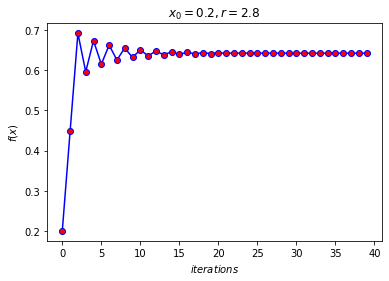

In [25]:
last_iter = plot_iter(f, r, x0)
print('The last iteration values is',last_iter) 